# Commodity Equity Alpha

The main approach in this model is examining and trading the relationship between physical producers / users equity alpha and commodities returns. The equity alpha for commodities producer is the excess return attribute to the individual companies. Equity investors may be attributing excess returns to commodity companies which the commodities market doesn't fully price in.

We'll first by using various commodity ETFs and their respective Commodity Futures. 

In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt
from   matplotlib.ticker import FuncFormatter

import statsmodels.api as sm
from   statsmodels.regression.rolling import RollingOLS

# Preparing data

In [2]:
df_eq = (pd.read_parquet(
    path = r"data/eq_px.parquet").
    query("variable == 'Adj Close'").
    pivot(index = "date", columns = "ticker", values = "value").
    pct_change().
    reset_index().
    melt(id_vars = ["date", "SPY"]).
    dropna())

In [3]:
df_fut = (pd.read_parquet(
    path = r"data/commod_px.parquet").
    assign(security = lambda x: x.security.str.split("1").str[0].str.strip()).
    pivot(index = "date", columns = "security", values = "PX_LAST").
    pct_change().
    reset_index().
    melt(id_vars = ["date"], var_name = "fut_ticker", value_name = "fut_rtn").
    dropna().
    assign(date = lambda x: pd.to_datetime(x.date).dt.date))

In [4]:
path     = os.path.join(r"data/tickers.xlsx")
df_namer = (pd.read_excel(
    io = path, sheet_name = "Sheet2")
    [["fut_ticker", "fut_name"]])

In [5]:
df_relationship = pd.read_excel(io = r"data/tickers.xlsx", sheet_name = "Sheet2")

In [6]:
df_ticker = (pd.read_excel(
    io         = r"data/tickers.xlsx", 
    sheet_name = "Sheet2").
    assign(
        tmp       = lambda x: x.Name.str.replace("VanEck", "").str.replace("ETF", "").str.replace("and", "&").str.replace("Metals", ""),
        group_var = lambda x: x.Ticker + " " + x.fut_ticker))

# Defining the model

First start by seperating out the alpha in equities. In this case use a 30 day rolling OLS regression and SPY as a benchmark. Below is a plot of the rolling alphas.

In [163]:
alpha_path = os.path.join(r"data", "ETFSPYAlpha.parquet")
df_alpha   = (pd.read_parquet(path = alpha_path, engine = "pyarrow"))

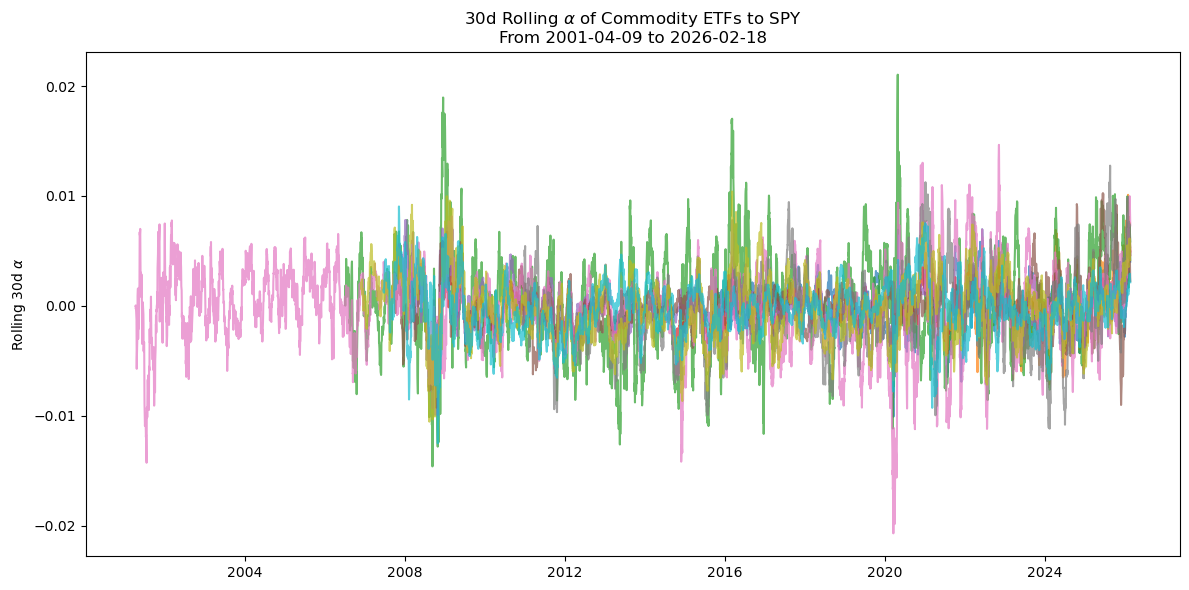

In [164]:
(df_alpha.pivot(
    index = "date", columns = "ticker", values = "const").
    plot(
        ylabel  = r"Rolling 30d $\alpha$",
        legend  = False,
        xlabel  = "",
        figsize = (12,6),
        alpha   = 0.7,
        title   = r"30d Rolling $\alpha$ of Commodity ETFs to SPY" + "\nFrom {} to {}".format(
            df_alpha.date.min(),
            df_alpha.date.max())))

plt.tight_layout()

In [165]:
df_combined = (df_relationship.rename(
    columns = {"Ticker": "ticker"}).
    assign(Name = lambda x: x.Name.str.replace("VanEck", "").str.replace("ETF", "")).
    merge(right = df_alpha, how = "inner", on = ["ticker"]).
    merge(right = df_fut, how = "inner", on = ["fut_ticker", "date"]))

In [171]:
def _get_resid(df: pd.DataFrame, q: int = 10) -> pd.DataFrame: 
    
    df_tmp = df.sort_index().assign(const = lambda x: x.const.shift()).dropna()
    df_out = (sm.OLS(
        endog  = df_tmp.fut_rtn,
        exog   = sm.add_constant(df_tmp.const)).
        fit().
        resid.
        to_frame(name = "resid").
        assign(
            lag_resid = lambda x: x.resid.shift(),
            decile    = lambda x: pd.qcut(x = x.resid, q = q, labels = [i + 1 for i in range(q)]).shift()).
        merge(right = df, how = "inner", on = ["date"]))
    
    return df_out

df_signal = (df_combined.assign(
    group_var = lambda x: x.ticker + " " + x.fut_ticker).
    set_index("date").
    groupby("group_var").
    apply(_get_resid, include_groups = False).
    reset_index())

In [172]:
def _model(df: pd.DataFrame) -> pd.DataFrame: 
    
    df_tmp = df.sort_index()
    model1 = (sm.OLS(
        endog  = df_tmp.fut_rtn,
        exog   = sm.add_constant(df_tmp.alpha)).
        fit())
    
    df_param_val = (model1.params.to_frame(
        name = "param_val").reset_index())
    
    df_pvalue = (model1.pvalues.to_frame(
        name = "pvalue").reset_index())
    
    df_tstat = (model1.tvalues.to_frame(
        name = "tstat").reset_index())
    
    df_out = (df_param_val.merge(
        right = df_pvalue, how = "inner", on = ["index"]).
        merge(right = df_tstat, how = "inner", on = ["index"]))
    
    return df_out

def _get_coefs(df: pd.DataFrame, q: int = 10) -> pd.DataFrame: 
    
    df_lag0 = _model(df).assign(model = "lag_0")
    df_lag  = df.sort_index().assign(alpha = lambda x: x.alpha.shift()).dropna()
    df_lag1 = _model(df_lag).assign(model = "lag_1")
    
    df_out = pd.concat([df_lag0, df_lag1])
    return df_out

df_coefs = (df_combined.assign(
    group_var = lambda x: x.ticker + " " + x.fut_ticker).
    set_index("date").
    rename(columns = {"const": "alpha"}).
    groupby("group_var").
    apply(_get_coefs))

Then we pass those rolling alphas into a regression against their respective commodities. Below is the number of accepted regressions. 

In [173]:
display(df_coefs.assign(
    tmp = lambda x: np.where((x.pvalue < 0.1) & (np.abs(x.tstat) > 1.6), 1, 0))
    [["index", "tmp", "model"]].
    reset_index().
    drop(columns = ["level_1", "group_var"]).
    rename(columns = {
        "index": "Param",
        "model": "Lag"}).
    replace({
        "alpha": r"$\alpha$",
        "const": r"$\beta$",
        "lag_0": "No Lag",
        "lag_1": "Lagged"}).
    groupby(["Param", "Lag"]).
    agg(["sum", "count"])
    ["tmp"].
    rename(columns = {
        "sum"  : "good_params",
        "count": "full_count"}).
    assign(tmp = lambda x: x.good_params / x.full_count).
    rename(columns = {
        "good_params": "Stat. Sig.",
        "full_count" : "Total",
        "tmp"        : "Ratio"}).
    apply(lambda x: np.round(x,3)))

Stat. Sig.  Total  Ratio
Param    Lag                             
$\alpha$ Lagged          19     52  0.365
         No Lag          39     52  0.750
$\beta$  Lagged          18     52  0.346
         No Lag          21     52  0.404

In [174]:
df_dt = (pd.read_parquet(
    path = r"data/commod_px.parquet").
    assign(security = lambda x: x.security.str.split("1").str[0].str.strip()).
    pivot(index = "date", columns = "security", values = "PX_LAST").
    diff().
    apply(lambda x: x / x.ewm(span = 10, adjust = False).std()).
    apply(lambda x: np.where(np.abs(x) == np.inf, np.nan, x)))

In [175]:
def _get_trend(df_dt: pd.DataFrame, window: int = 30) -> pd.DataFrame: 
    
    df_out = (df_dt.apply(
        lambda x: x.ewm(span = window, adjust = False).mean()).
        reset_index().
        melt(id_vars = "date", value_name = "signal").
        assign(window = window))

    return df_out

df_trend = (pd.concat([
    _get_trend(df_dt, window) for window in [5, 30, 100, 200]]).
    rename(columns = {"security": "fut_ticker"}).
    assign(date = lambda x: pd.to_datetime(x.date).dt.date))

In [176]:
df_namer_tmp = (df_namer.assign(
    ticker = lambda x: x.group_var.str.split(" ").str[0],
    Name   = lambda x: x.Name.str.strip()))

In [177]:
df_corr = (df_alpha[
    ["ticker", "date", "const"]].
    rename(columns = {"const": "alpha"}).
    merge(right = df_namer_tmp, how = "outer", on = ["ticker"]).
    merge(right = df_trend, how = "inner", on = ["fut_ticker", "date"])
    [["ticker", "fut_ticker", "signal", "window", "alpha"]].
    groupby(["ticker", "fut_ticker", "window"]).
    agg("corr")
    [["alpha"]].
    query("alpha != 1").
    reset_index().
    drop(columns = ["level_3"]))

In [178]:
renamer = df_namer_tmp.set_index("ticker").Name.to_dict()

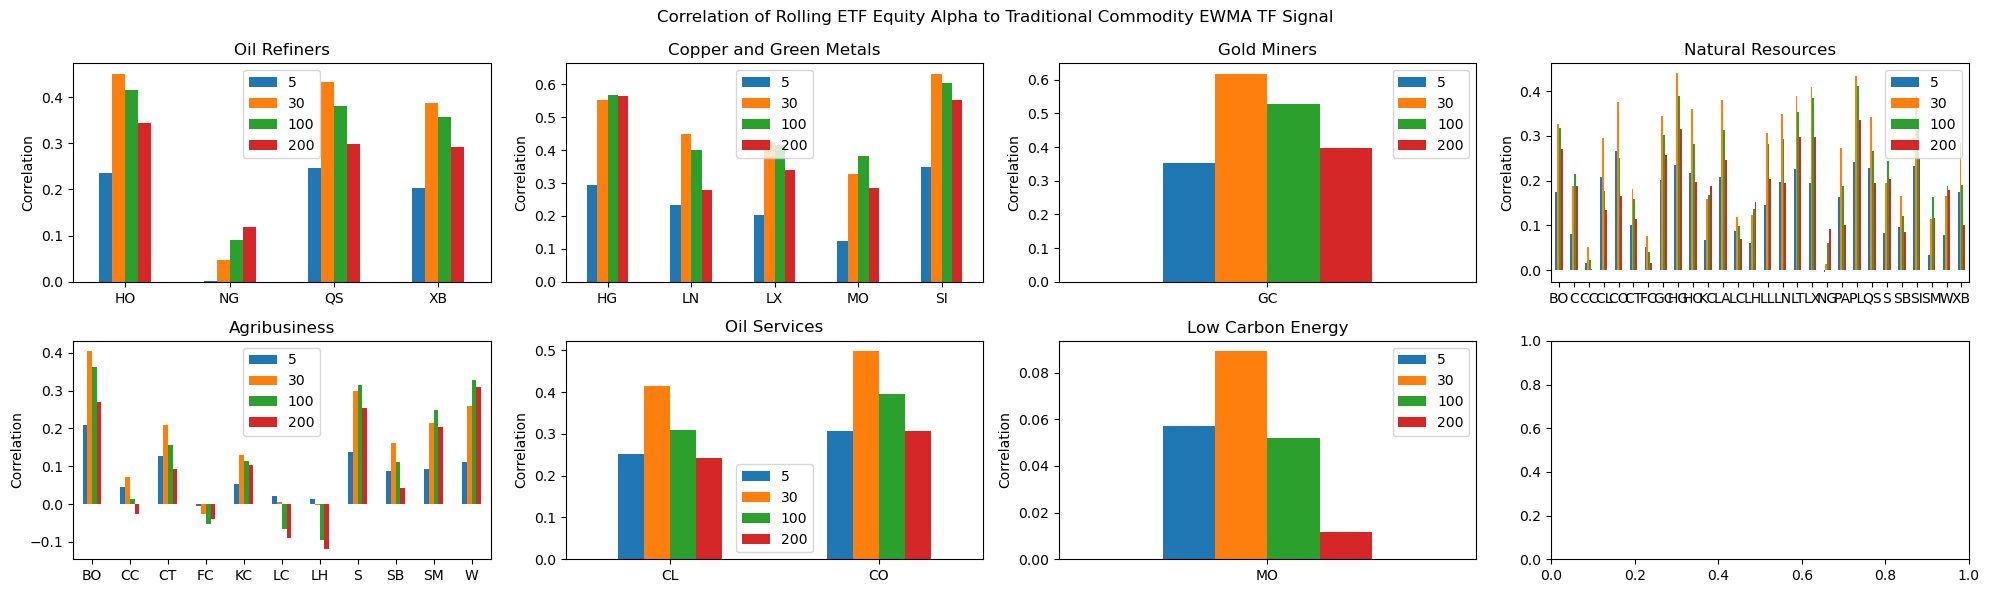

In [179]:
groups    = df_corr.ticker.drop_duplicates().sort_values().to_list()
fig, axes = plt.subplots(ncols = 4, nrows = 2, figsize = (20,6)) 

for group, ax in zip(groups, axes.flatten()): 

    (df_corr.query(
        "ticker == @group").
        rename(columns = {"window": ""}).
        pivot(index = "fut_ticker", columns = "", values = "alpha").
        plot(
            ax     = ax,
            kind   = "bar",
            rot    =  0,
            title  = renamer[group],
            xlabel = "",
            ylabel = "Correlation"))

fig.suptitle("Correlation of Rolling ETF Equity Alpha to Traditional Commodity EWMA TF Signal")
plt.tight_layout()

# Trading the Residual of OLS Model

In [180]:
df_signal_rtn = (df_signal.assign(
    signal_rtn = lambda x: -np.sign(x.lag_resid) * x.fut_rtn).
    rename(columns = {"group_var": ""}))

Here is the results of trading the residuals of that regression

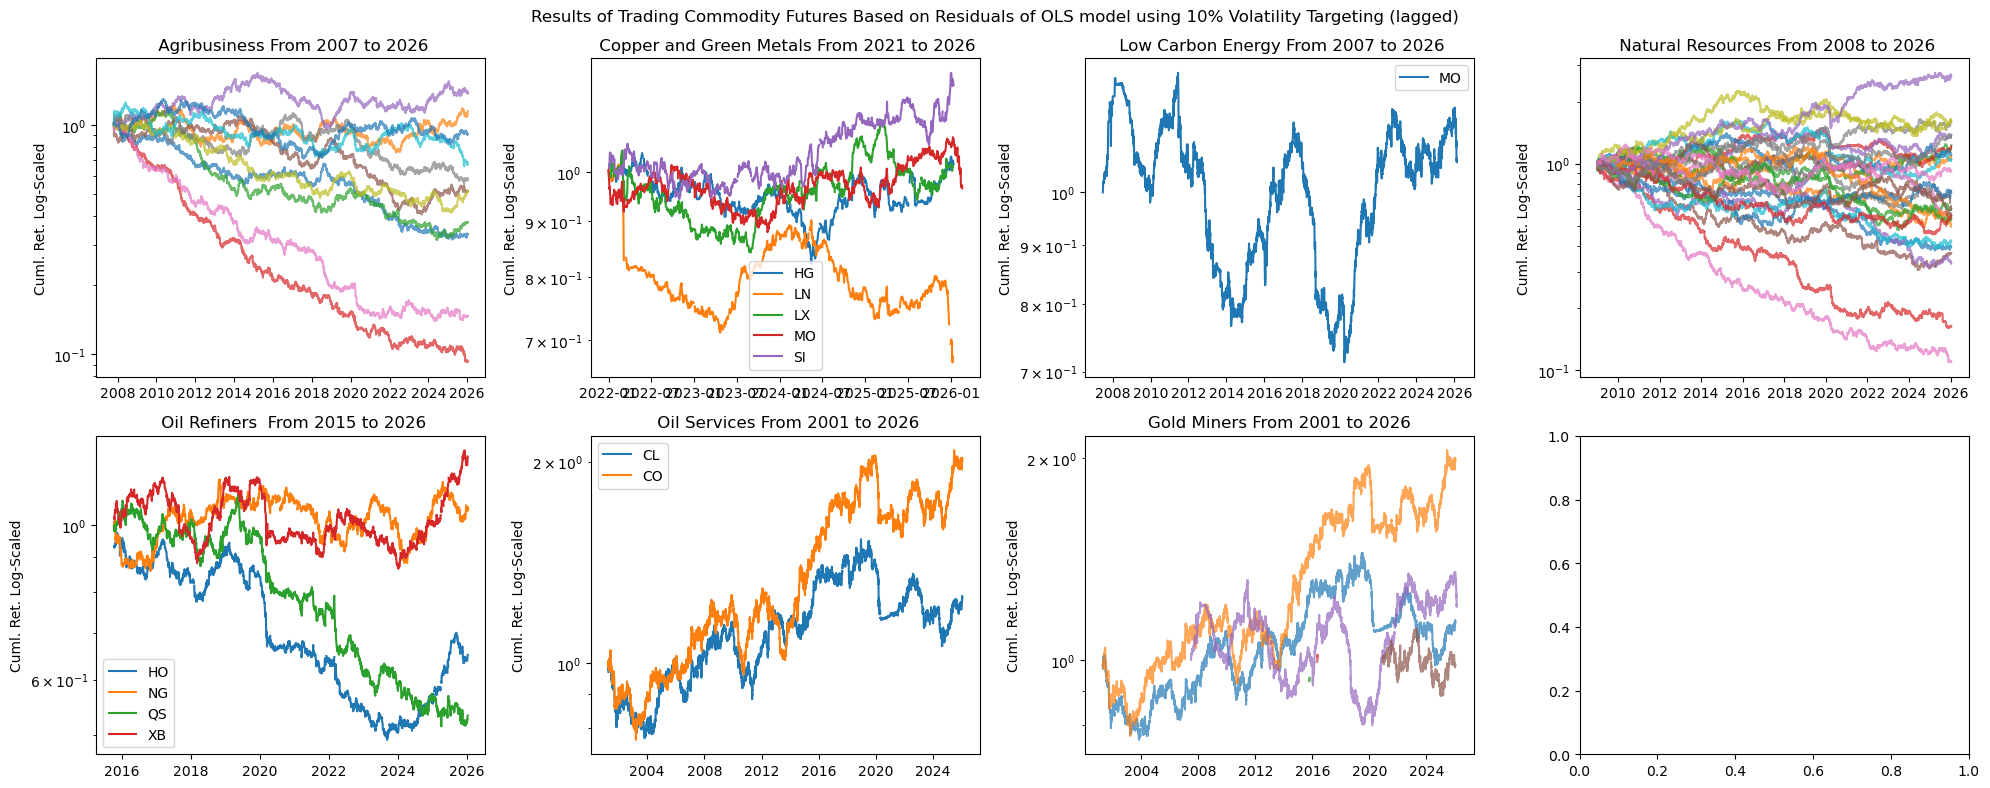

In [181]:
groups    = df_signal_rtn.Name.drop_duplicates().sort_values().to_list()
const     = 2
fig, axes = plt.subplots(ncols = 4, nrows = 2, figsize = (10 * const, 4 * const)) 

for group, ax in zip(groups, axes.flatten()):

    df_tmp_wider = (df_signal_rtn.query(
        "Name == @group").
        drop(columns = [""]).
        rename(columns = {"fut_ticker": ""}).
        pivot(index = "date", columns = "", values = "signal_rtn").
        apply(lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std().shift() * np.sqrt(252)))).
        apply(lambda x: np.where(np.abs(x) > 0.2, np.nan, x)).
        apply(lambda x: np.cumprod(1 + x)))

    tickers = df_tmp_wider.columns.to_list()
    
    if len(tickers) > 5:
        legend_bool = False
        alpha_level = 0.7
    
    else:
        legend_bool = True
        alpha_level = 1

    df_tmp_wider.plot(
        ax     = ax,
        legend = legend_bool,
        alpha  = alpha_level,
        logy   = True,
        xlabel = "",
        ylabel = "Cuml. Ret. Log-Scaled",
        title  = group + "From {} to {}".format(
            df_tmp_wider.index.min().year,
            df_tmp_wider.index.max().year))

fig.suptitle("Results of Trading Commodity Futures Based on Residuals of OLS model using 10% Volatility Targeting (lagged)")
plt.tight_layout()
fig.savefig(r"latex/NaiveTradingOLS.png", dpi = 600)

In [182]:
df_signal_sharpe = (df_signal_rtn.pivot(
    index = "date", columns = ["Name", "fut_ticker"], values = "signal_rtn").
    apply(lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std().shift() * np.sqrt(252)))).
    reset_index().
    melt(id_vars = [("date", "")]).
    rename(columns = {("date", ""): "date"}).
    drop(columns = ["date"]).
    dropna().
    assign(Name = lambda x: x.Name.str.strip()).
    groupby(["Name", "fut_ticker"]).
    agg(lambda x: x.mean() / x.std() * np.sqrt(252)).
    reset_index())

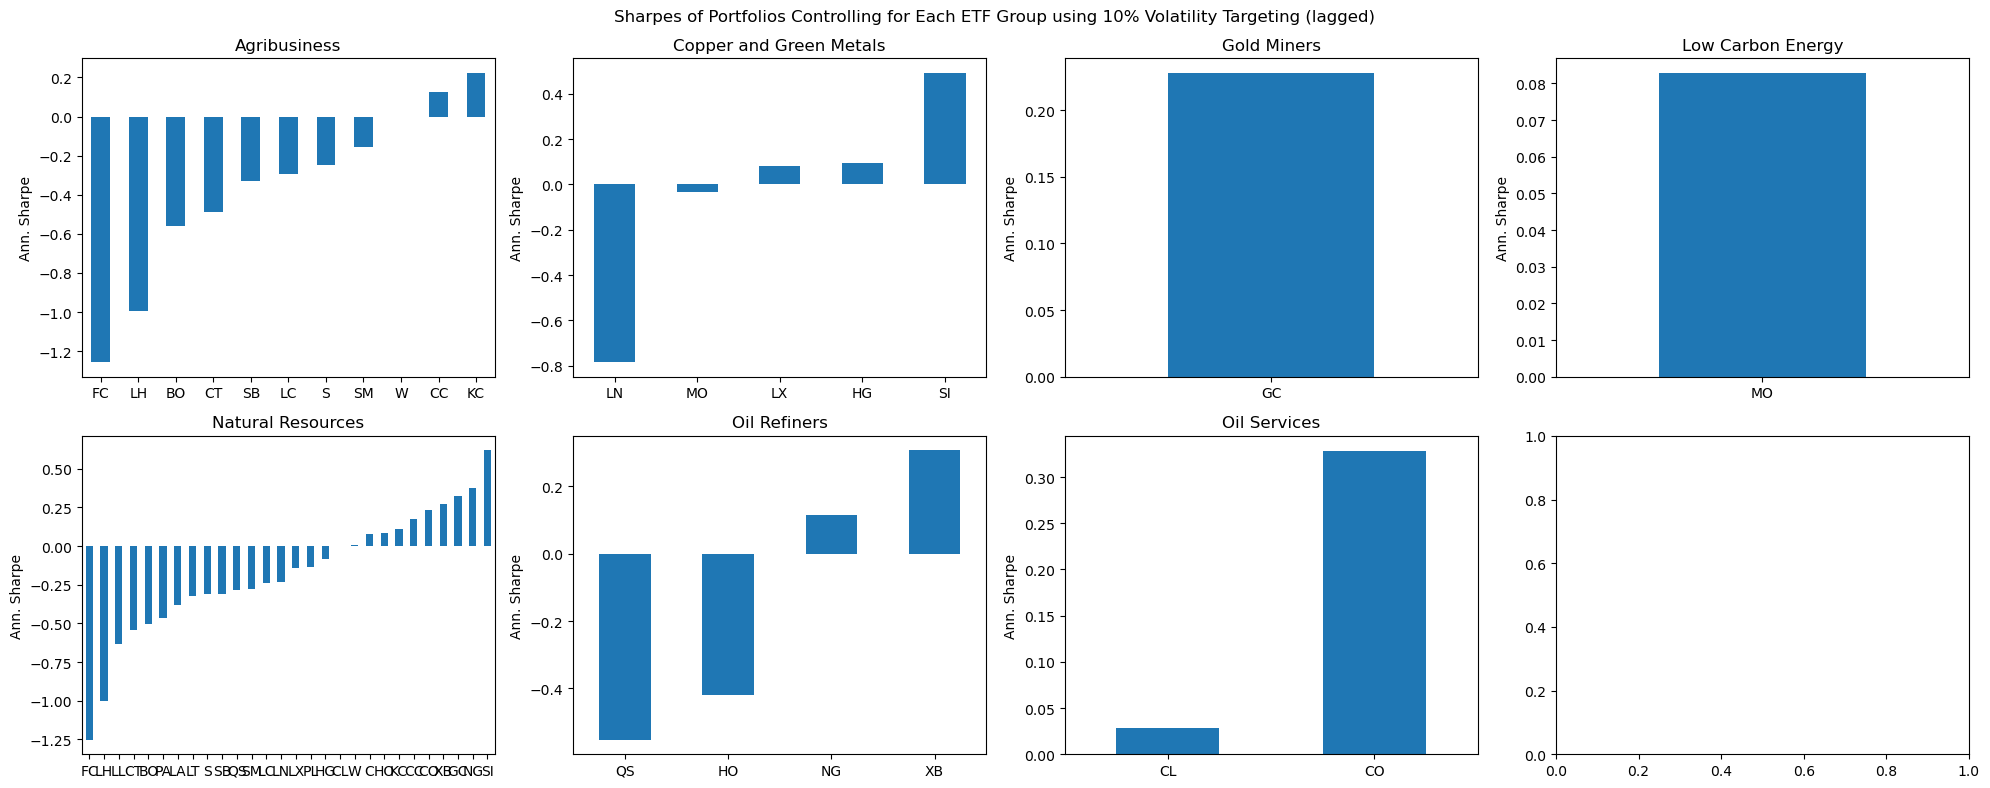

In [183]:
names     = df_signal_sharpe.Name.drop_duplicates().sort_values().to_list()
const     = 2
fig, axes = plt.subplots(ncols = 4, nrows = 2, figsize = (10 * const, 4 * const)) 

for name, ax in zip(names, axes.flatten()):

    (df_signal_sharpe.query(
        "Name == @name").
        set_index("fut_ticker").
        sort_values("value").
        drop(columns = ["Name"]).
        plot(
            kind   = "bar",
            ax     = ax,
            legend = False,
            rot    = 0,
            xlabel = "",
            ylabel = "Ann. Sharpe",
            title  = name))


fig.suptitle("Sharpes of Portfolios Controlling for Each ETF Group using 10% Volatility Targeting (lagged)")
plt.tight_layout()

# Trading Optimized Residuals of OLS Model

In [184]:
df_decile_sharpe = (df_signal[
    ["group_var", "decile", "fut_rtn"]].
    dropna().
    groupby(["group_var", "decile"]).
    agg(lambda x: x.mean() / x.std() * np.sqrt(252)).
    reset_index().
    rename(columns = {"fut_rtn": "sharpe"}))

In [185]:
df_grouper = (df_decile_sharpe.query(
    "decile == [1,2,9,10]").
    assign(group = lambda x: np.where(x.decile <= 2, "lower", "upper")))

In [186]:
df_opt_signal = (df_grouper[
    ["group_var", "group", "sharpe"]].
    assign(sharpe = lambda x: np.where(np.abs(x.sharpe) > 0.2, x.sharpe, 0)).
    groupby(["group_var", "group"]).
    agg("prod").
    reset_index().
    assign(scaler = lambda x: np.where(x.sharpe > 0, 1, np.nan)).
    drop(columns = ["sharpe"]).
    merge(right = df_grouper, how = "inner", on = ["group_var", "group"]).
    assign(signal = lambda x: x.scaler * x.sharpe).
    dropna())

In [187]:
df_opt_rtn = (df_signal.merge(
    right = df_opt_signal, how = "right", on = ["decile", "group_var"]).
    assign(
        Name       = lambda x: x.Name.str.replace("xa0", "").str.strip(),
        signal_rtn = lambda x: np.sign(x.signal) * x.fut_rtn))

In [188]:
df_opt_rsk_rtn = (df_opt_rtn.pivot(
    index = "date", columns = "group_var", values = "signal_rtn").
    apply(lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std().shift() * np.sqrt(252)))).
    apply(lambda x: np.where(np.abs(x) == np.inf, np.nan, x)).
    reset_index().
    melt(id_vars = "date").
    assign(
        group  = lambda x: x.group_var.str.split(" ").str[0],
        ticker = lambda x: x.group_var.str.split(" ").str[1]).
    dropna())

In [189]:
renamer = (df_signal[
    ["ticker", "Name"]].
    assign(Name = lambda x: x.Name.str.strip()).
    drop_duplicates().
    set_index("ticker").
    Name.
    to_dict())

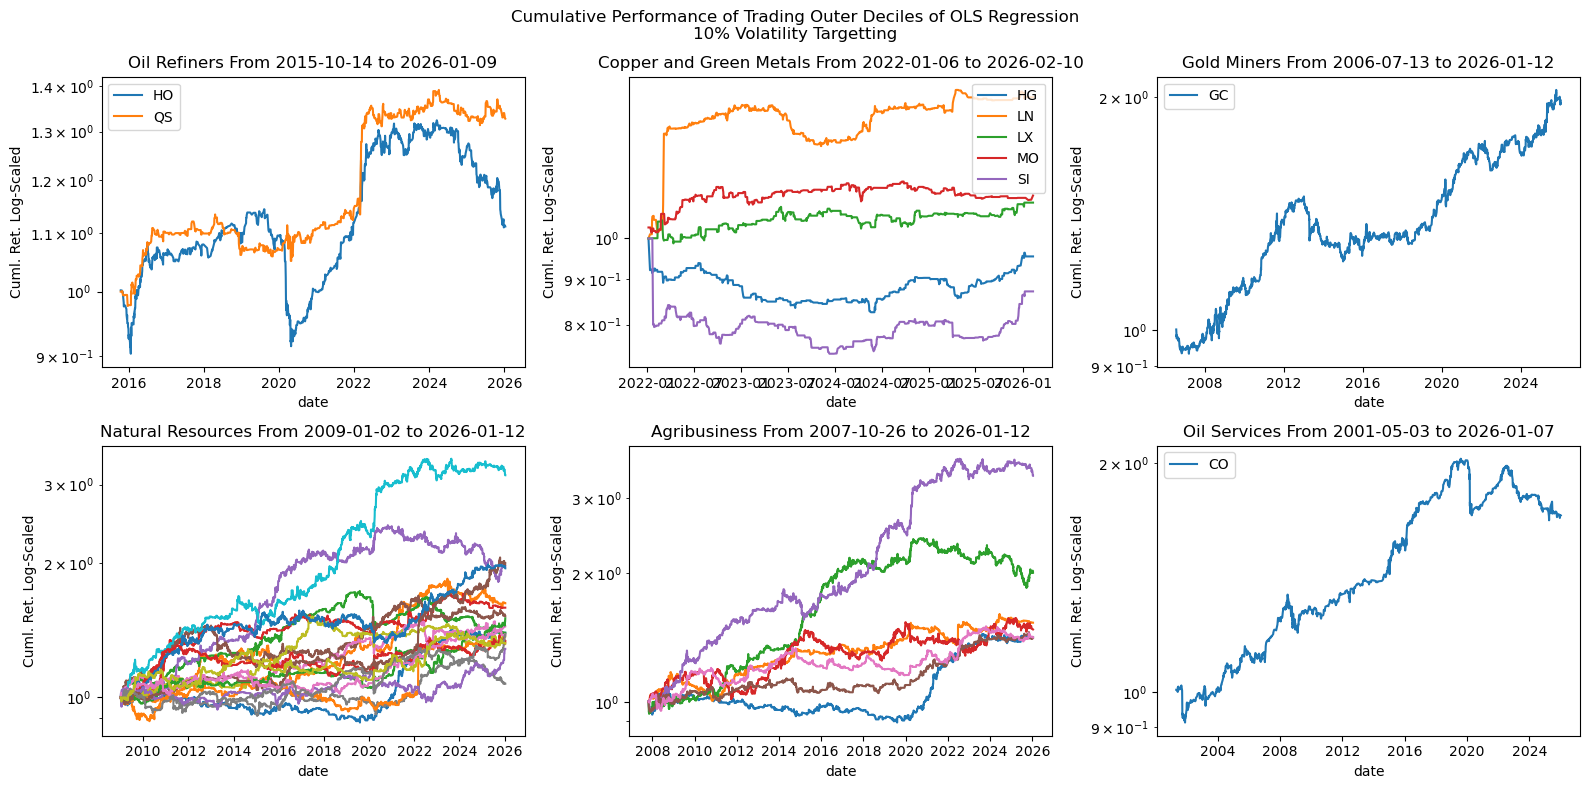

In [191]:
groups    = df_opt_rsk_rtn.group.drop_duplicates().sort_values().to_list()
fig, axes = plt.subplots(ncols = 3, nrows = 2, figsize = (16,8))

for group, ax in zip(groups, axes.flatten()): 
    
    df_tmp = (df_opt_rsk_rtn.query(
        "group == @group").
        rename(columns = {"ticker": ""}).
        query("value <= 0.4").
        pivot(index = "date", columns = "", values = "value").
        fillna(0).
        apply(lambda x: np.cumprod(1 + x)))

    if len(df_tmp.columns.to_list()) > 5: 
        legend_bool = False
    else: 
        legend_bool = True
    
    (df_tmp.
        plot(
            logy   = True,
            ax     = ax,
            legend = legend_bool,
            ylabel = "Cuml. Ret. Log-Scaled",
            title  = "{} From {} to {}".format(
                renamer[group],
                df_tmp.index.min(),
                df_tmp.index.max())))
    
fig.suptitle("Cumulative Performance of Trading Outer Deciles of OLS Regression\n10% Volatility Targetting")
plt.tight_layout()

In [192]:
df_opt_rtn_wider = (df_opt_rtn.pivot(
    index = "date", columns = "group_var", values = "signal_rtn"))

In [193]:
df_lag1 = (df_opt_rtn_wider.
    apply(lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std().shift() * np.sqrt(252)))).
    apply(lambda x: np.where(np.abs(x) == np.inf, np.nan, x)).
    reset_index().
    melt(id_vars = "date").
    assign(
        raw_rtn = lambda x: x.value.fillna(0),
        group   = "lag_1").
    rename(columns = {"value": "adj_rtn"}))

df_lag0 = (df_opt_rtn_wider.
    apply(lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std()* np.sqrt(252)))).
    apply(lambda x: np.where(np.abs(x) == np.inf, np.nan, x)).
    reset_index().
    melt(id_vars = "date").
    assign(
        raw_rtn = lambda x: x.value.fillna(0),
        group   = "lag_0").
    rename(columns = {"value": "adj_rtn"}))

In [194]:
df_namer = (df_signal[
    ["group_var", "Name", "fut_ticker"]].
    drop_duplicates())

The resulting sharpes are not reasonably strong in this case, two volatility targetting methods are used. One is done perfectly and the other is done with a 1-day lag. In real life scenarios, perfect volatility targetting is not possible, but one day volatility targetting could lead to outsized losses due to high intraday volatility within some commodities. Therefore, both calculations are used to give a sharpe-bound. 

In [195]:
display(pd.concat([
    df_lag1, df_lag0]).
    melt(id_vars = ["date", "group_var", "group"]).
    dropna().
    drop(columns = ["date"]).
    merge(right = df_namer, how = "inner", on = ["group_var"]).
    drop(columns = ["group_var"]).
    groupby(["Name", "fut_ticker", "group", "variable"]).
    agg(lambda x: x.mean() / x.std() * np.sqrt(252)).
    reset_index().
    rename(columns = {
        "group"     : "Target Type",
        "fut_ticker": "Fut",
        "variable"  : ""}).
    replace({
        "lag_0"   : "Perfect Targetting",
        "lag_1"   : "Vol Targetting",
        "adj_rtn" : "Adj. Ret",
        "raw_rtn" : "Raw Return"}).
    pivot(index = ["Name", "Fut"], columns = ["Target Type", ""], values = "value").
    apply(lambda x: np.round(x,3)))

Target Type                   Perfect Targetting            Vol Targetting  \
                                        Adj. Ret Raw Return       Adj. Ret   
Name                      Fut                                                
 Agribusiness             BO               0.757      0.320          0.984   
                          CT               1.069      0.451          1.160   
                          FC               1.035      0.618          0.976   
                          KC               0.642      0.383          0.577   
                          LH               1.852      1.103          1.756   
                          S                0.988      0.417          0.999   
                          SM               0.966      0.408          0.998   
 Copper and Green Metals  HG               0.780      0.154         -0.365   
                          LN               1.650      0.454          1.386   
                          LX               0.870      0.171          1.055   
                          MO               0.386      0.078          1.294   
                          SI               1.603      0.317         -0.547   
 Low Carbon Energy        MO               1.190      0.513          1.064   
 Natural Resources        BO               0.999      0.408          1.045   
                          C                0.807      0.466          0.795   
                          CO               1.108      0.458          0.993   
                          CT               1.488      0.606          1.444   
                          FC               1.037      0.599          1.044   
                          GC               1.219      0.703          1.046   
                          HG               1.272      0.518          1.106   
                          HO               0.362      0.137          0.293   
                          LC               0.966      0.394          0.967   
                          LH               1.804      1.038          1.760   
                          LL               1.148      0.658          1.084   
                          LN               0.713      0.289          0.706   
                          LT               1.493      0.603          1.346   
                          PA               0.825      0.337          0.847   
                          PL               0.428      0.175          0.700   
                          QS               1.310      0.541          1.287   
                          S                0.992      0.405          1.023   
                          SI               1.247      0.508          0.979   
                          SM               0.894      0.365          0.892   
 Oil Refiners             HO               0.471      0.196          0.348   
                          QS               1.467      0.470          1.433   
 Oil Services             CO               1.273      0.632          1.079   
Gold Miners               GC               1.078      0.666          0.935   

Target Type                               
                              Raw Return  
Name                      Fut             
 Agribusiness             BO       0.415  
                          CT       0.489  
                          FC       0.583  
                          KC       0.345  
                          LH       1.046  
                          S        0.422  
                          SM       0.421  
 Copper and Green Metals  HG      -0.072  
                          LN       0.382  
                          LX       0.207  
                          MO       0.261  
                          SI      -0.108  
 Low Carbon Energy        MO       0.459  
 Natural Resources        BO       0.426  
                          C        0.459  
                          CO       0.411  
                          CT       0.588  
                          FC       0.603  
                          GC       0.604  
           

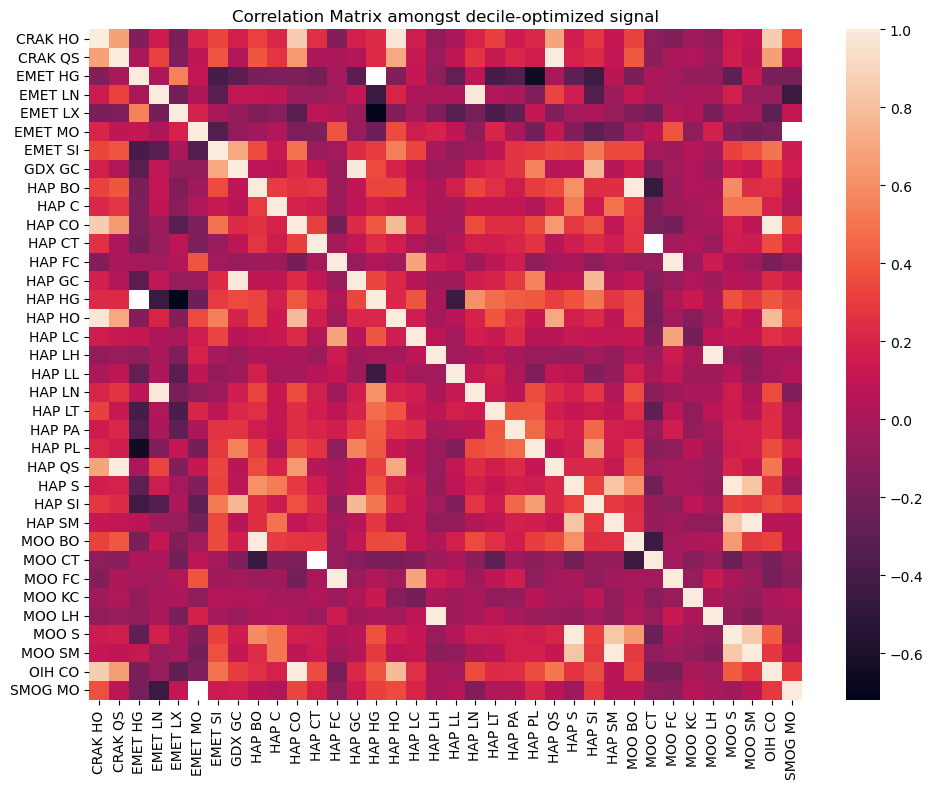

In [196]:
df_corr = (df_opt_rsk_rtn.pivot(
    index = "date", columns = "group_var", values = "value").
    corr())

fig, axes = plt.subplots(figsize = (10,8))

sns.heatmap(
    data  = df_corr,
    cbar  = True,
    annot = False)

axes.set_xlabel("")
axes.set_ylabel("")

axes.set_title("Correlation Matrix amongst decile-optimized signal")
plt.tight_layout()

In [197]:
df_name_rtn = (df_opt_rtn.pivot(
    index = "date", columns = ["Name", "fut_ticker"], values = "signal_rtn").
    fillna(0).
    apply(lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std().shift() * np.sqrt(252)))).
    apply(lambda x: np.where(np.abs(x) > 0.4, np.nan, x)).
    reset_index().
    melt(id_vars = [("date", "")], value_name = "rtn").
    rename(columns = {("date", ""): "date"}).
    drop(columns = ["fut_ticker"]).
    dropna().
    groupby(["date", "Name"]).
    agg("mean").
    assign(group = "vol_target"))

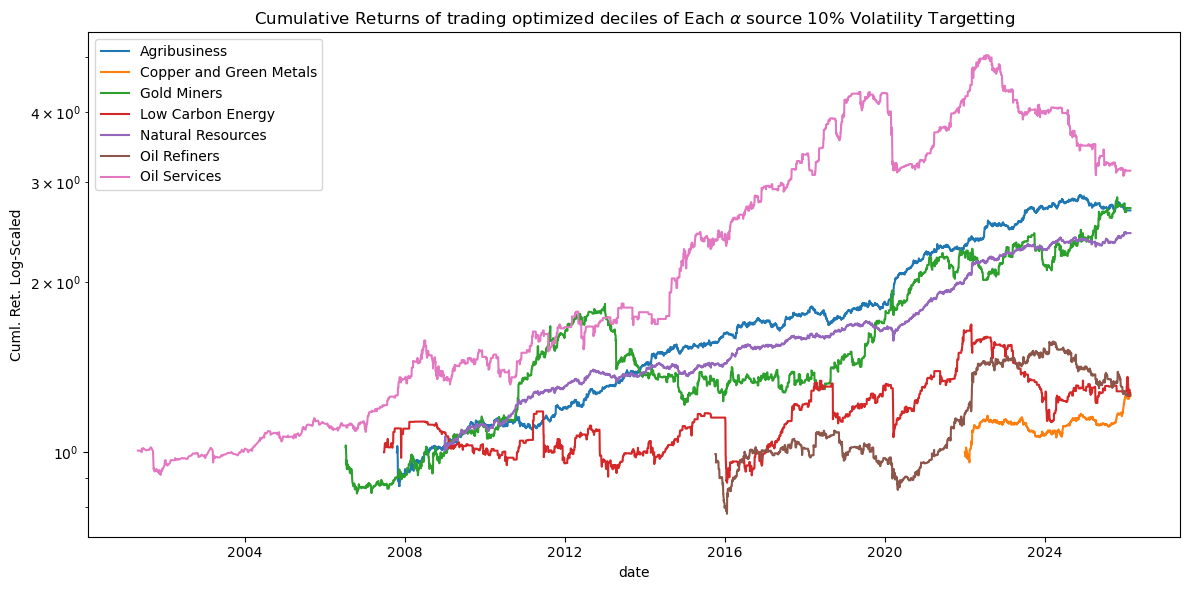

In [198]:
fig, axes = plt.subplots(figsize = (12,6))

(df_name_rtn.
    reset_index().
    rename(columns = {"Name": ""}).
    pivot(index = "date", columns = "", values = "rtn").
    apply(lambda x: np.cumprod(1 + x)).
    plot(
        ax      = axes,
        logy    = True,
        ylabel  = "Cuml. Ret. Log-Scaled",
        title   = r"Cumulative Returns of trading optimized deciles of Each $\alpha$ source 10% Volatility Targetting"))

out_path = os.path.join(r"latex", "OptDecileETFGroups.png")
fig.savefig(out_path, dpi = 300)
plt.tight_layout()

In [199]:
df_perf_name_rtn = (df_opt_rtn.pivot(
    index = "date", columns = ["Name", "fut_ticker"], values = "signal_rtn").
    fillna(0).
    apply(lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std() * np.sqrt(252)))).
    apply(lambda x: np.where(np.abs(x) > 0.4, np.nan, x)).
    reset_index().
    melt(id_vars = [("date", "")], value_name = "rtn").
    rename(columns = {("date", ""): "date"}).
    drop(columns = ["fut_ticker"]).
    dropna().
    groupby(["date", "Name"]).
    agg("mean").
    assign(group = "perf"))

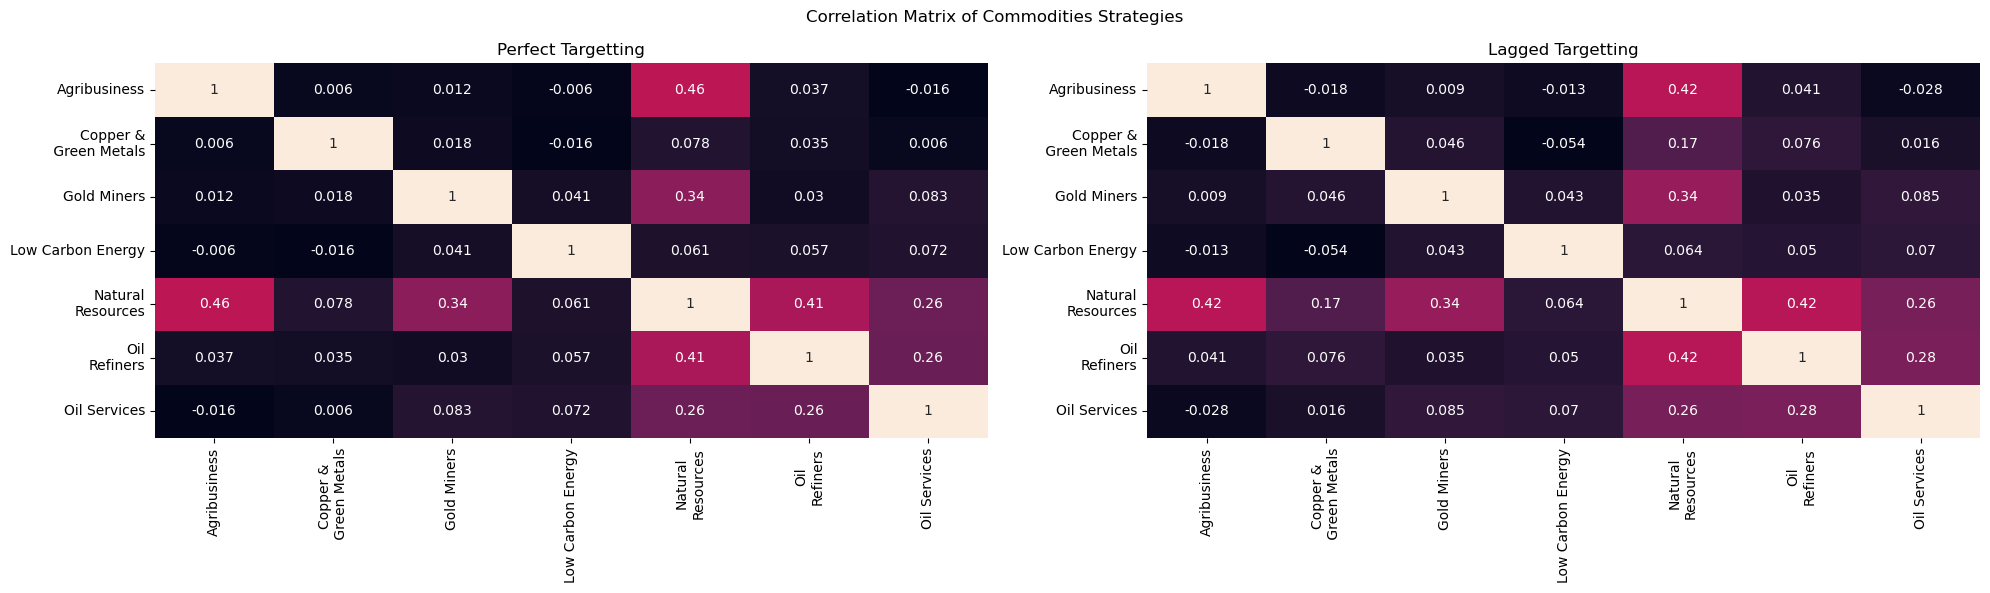

In [200]:
df_combined = (pd.concat([
    df_perf_name_rtn, df_name_rtn]).
    reset_index())

groups    = df_combined.group.drop_duplicates().sort_values().to_list()
fig, axes = plt.subplots(ncols = len(groups), figsize = (20,6)) 

renamer = {
    "perf"      : "Perfect Targetting",
    "vol_target": "Lagged Targetting"}

for group, ax in zip(groups, axes.flatten()): 

    df_corr = (df_combined.query(
        "group == @group").
        assign(Name = lambda x: x.Name.str.replace("and", "&\n").str.replace("l R", "l\nR")).
        pivot(index = "date", columns = "Name", values = "rtn").
        corr().
        apply(lambda x: np.round(x,3)))

    sns.heatmap(
        data  = df_corr,
        annot = True,
        ax    = ax,
        cbar  = False)

    ax.set_title(renamer[group])
    ax.set_xlabel("")
    ax.set_ylabel("")

fig.suptitle("Correlation Matrix of Commodities Strategies")
plt.tight_layout()

out_path = os.path.join("latex", "CorrelationMatrix.png")
fig.savefig(out_path, dpi = 300)

In [201]:
display(pd.concat([
    df_perf_name_rtn, df_name_rtn]).
    reset_index().
    rename(columns = {"rtn": "raw_rtn"}).
    assign(adj_rtn = lambda x: np.where(x.raw_rtn == 0, np.nan, x.raw_rtn)).
    melt(id_vars = ["date", "Name", "group"]).
    dropna().
    drop(columns = ["date"]).
    groupby(["Name", "group", "variable"]).
    agg(lambda x: x.mean() / x.std() * np.sqrt(252)).
    reset_index().
    rename(columns = {
        "group"   : "Vol. Target",
        "variable": ""}).
    replace({
        "perf"      : "Perfect Targetting",
        "vol_target": "Vol Targetting",
        "raw_rtn"   : "Raw Sharpe",
        "adj_rtn"   : "Adj Sharpe"}).
    pivot(index = "Name", columns = ["Vol. Target", ""], values = "value").
    apply(lambda x: np.round(x,3)))

Vol. Target             Perfect Targetting            Vol Targetting  \
                                Adj Sharpe Raw Sharpe     Adj Sharpe   
Name                                                                   
Agribusiness                         1.291      1.204          1.215   
Copper and Green Metals              1.021      0.856          1.075   
Gold Miners                          1.088      0.691          0.853   
Low Carbon Energy                    0.828      0.368          0.387   
Natural Resources                    1.614      1.605          1.468   
Oil Refiners                         0.741      0.481          0.454   
Oil Services                         1.411      0.698          1.168   

Vol. Target                         
                        Raw Sharpe  
Name                                
Agribusiness                 1.133  
Copper and Green Metals      0.900  
Gold Miners                  0.541  
Low Carbon Energy            0.172  
Natural Resources            1.459  
Oil Refiners                 0.295  
Oil Services                 0.578

In [202]:
df_lagged = (df_opt_rtn.pivot(
    index = "date", columns = ["Name", "fut_ticker"], values = "signal_rtn").
    fillna(0).
    apply(lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std().shift() * np.sqrt(252)))).
    apply(lambda x: np.where(np.abs(x) > 0.4, np.nan, x)).
    mean(axis = 1).
    to_frame(name = "lagged_rtn"))

df_perf = (df_opt_rtn.pivot(
    index = "date", columns = ["Name", "fut_ticker"], values = "signal_rtn").
    fillna(0).
    apply(lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std() * np.sqrt(252)))).
    apply(lambda x: np.where(np.abs(x) > 0.4, np.nan, x)).
    mean(axis = 1).
    to_frame(name = "perf"))

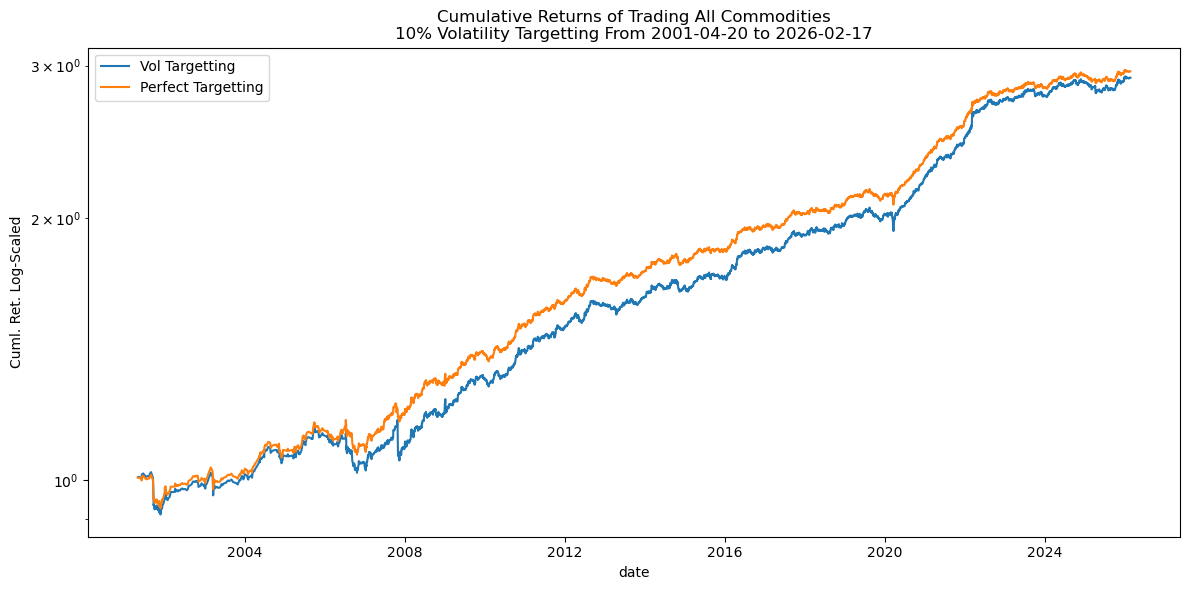

In [203]:
df_combined = (df_lagged.merge(
    right = df_perf, how = "inner", on = ["date"]).
    dropna())


(df_combined.
    apply(lambda x: np.cumprod(1 + x)).
    rename(columns = {
        "lagged_rtn": "Vol Targetting",
        "perf"      : "Perfect Targetting"}).
    plot(
        logy    = True,
        figsize = (12,6),
        ylabel  = "Cuml. Ret. Log-Scaled",
        title   = "Cumulative Returns of Trading All Commodities\n10% Volatility Targetting From {} to {}".format(
            df_perf.index.min(),
            df_perf.index.max())))

plt.tight_layout()

In [204]:
(df_combined.reset_index().melt(
    id_vars = "date", value_name = "raw_rtn").
    assign(adj_rtn = lambda x: np.where(x.raw_rtn == 0, np.nan, x.raw_rtn)).
    melt(id_vars = ["date", "variable"], var_name = "rtn_group", value_name = "rtn_val").
    drop(columns = ["date"]).
    dropna().
    groupby(["variable", "rtn_group"]).
    agg(lambda x: x.mean() / x.std() * np.sqrt(252)).
    reset_index().
    replace({
        "lagged_rtn": "Vol Targetted",
        "perf"      : "Perf Targetted"}).
    rename(columns = {"rtn_group": ""}).
    pivot(index = "variable", columns = "", values = "rtn_val").
    rename(columns = {
        "adj_rtn": "Adjusted Sharpe",
        "raw_rtn": "Raw Sharpe"}).
    apply(lambda x: np.round(x,3)))

,Adjusted Sharpe,Raw Sharpe
variable,,
Perf Targetted,1.423,1.422
Vol Targetted,1.209,1.207


# Trading Deciles Out-of-Sample

In [227]:
oos_path     = os.path.join(r"data\OOSETFAlphaResid.parquet")
df_oos_resid = (pd.read_parquet(
    path = oos_path, engine = "pyarrow")
    [["group_var", "date", "resid"]].
    rename(columns = {"resid": "oos_resid"}).
    dropna())

df_is_resid = (df_signal[
    ["group_var", "date", "resid"]].
    rename(columns = {"resid": "is_resid"}))

In [230]:
df_combined_resid = (df_oos_resid.merge(
    right = df_is_resid, how = "inner", on = ["group_var", "date"]))

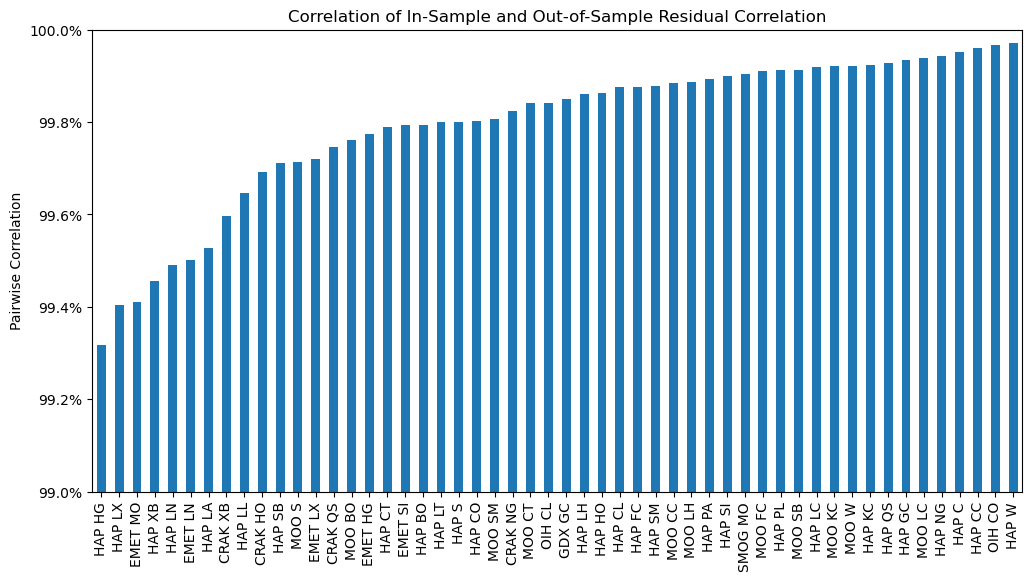

In [254]:
fig, axes = plt.subplots(figsize = (12,6))

(df_combined_resid.drop(
    columns = ["date"]).
    groupby("group_var").
    agg("corr").
    query("is_resid != 1").
    reset_index().
    drop(columns = ["oos_resid", "level_1"]).
    set_index("group_var").
    sort_values("is_resid").
    plot(
        kind = "bar",
        legend = False,
        xlabel = "",
        ax     = axes,
        ylim   = (0.99,1),
        ylabel = "Pairwise Correlation",
        title  = "Correlation of In-Sample and Out-of-Sample Residual Correlation"))

axes.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:.1%}"))